# 07 Decode Contract v1

이 노트북의 목적은 **학습된 `.pth` 모델이 출력한 192개 lane prior 후보를 어떤 decoder/NMS 규칙으로 최종 lane으로 확정할지** 정하는 것이다.

이번 단계에서 결정하는 것은 주행 제어가 아니라, 모델 출력 후보를 lane 후보로 정리하는 **lane decoder contract**다. 이후 노트북에서 ONNX export, PyTorch/ONNX parity, Pi runtime parity, 그리고 주행용 postprocess contract를 따로 검증한다.

## 이번 노트북의 판단 범위

비교 대상은 같은 raw model output 위에서만 바꾼다.

1. `topk_only`: 예전 03/06 계열 fallback. confidence threshold 이후 score 상위 `max_lanes`만 남긴다.
2. `fallback_mean_abs_valid`: 12번 학습 노트북 validation에서 사용한 Python fallback. 전체 valid x offset 평균 거리로 중복을 제거한다.
3. `official_overlap_python`: 공식 CUDA NMS 커널을 Python으로 옮긴 버전. `start_y`와 `length`로 lane이 실제 존재하는 y 구간을 잡고, 겹치는 구간의 평균 x 거리 `< nms_thres`이면 중복으로 본다.

주의: CLRKDNet 코드의 공식 NMS는 `lineiou_loss.py`의 IoU 수식을 그대로 쓰는 방식이 아니라, CUDA 커널 안에서 평균 x 거리 threshold를 쓰는 방식이다. 그래서 이 노트북에서는 이 구현을 `official_overlap_python`이라고 부른다.

In [1]:
from pathlib import Path
import os
import sys
import json
import time
import math
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import torch

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

from IPython.display import display, Image, Markdown

EXP_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild")
SHARED_LANE_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane")
DATASET_DIR = SHARED_LANE_ROOT / "map_culane_localfit_train_field1_field2_v1"
RAW_ROOT = SHARED_LANE_ROOT / "raw"
HOLDOUT_ROOT = SHARED_LANE_ROOT / "holdout"

RUN_DIR = EXP_ROOT / "colab_outputs" / "MapLane_LocalFit_Field12_v1_full" / "20260509_102232_lr_1e-04_b_8"
CODE_DIR = RUN_DIR / "code"
CONFIG_PATH = EXP_ROOT / "colab_outputs" / "meta" / "MapLane_LocalFit_Field12_v1_ResNet18_full.py"
BEST_CKPT = RUN_DIR / "ckpt" / "best.pth"

REVIEW_ROOT = EXP_ROOT / "review_outputs" / "07_decode_contract_v1"
OVERLAY_DIR = REVIEW_ROOT / "overlays"
TABLE_DIR = REVIEW_ROOT / "tables"
VIDEO_DIR = REVIEW_ROOT / "videos"
for d in [REVIEW_ROOT, OVERLAY_DIR, TABLE_DIR, VIDEO_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Keep Run All reasonably fast on CPU. Increase these after the first review if needed.
MAX_VAL_FRAMES = 96
MAX_FIELD3_FRAMES = 160
MAX_HOLDOUT_FRAMES = 120
CONF_THRESHOLDS = [0.30, 0.35, 0.40]
NMS_MODES = ["topk_only", "fallback_mean_abs_valid", "official_overlap_python"]
SELECTED_REVIEW_CONF = 0.35
WRITE_SEQUENCE_VIDEOS = True

print('EXP_ROOT:', EXP_ROOT)
print('REVIEW_ROOT:', REVIEW_ROOT)

EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild
REVIEW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1


In [2]:
required_paths = {
    'CODE_DIR': CODE_DIR,
    'CONFIG_PATH': CONFIG_PATH,
    'BEST_CKPT': BEST_CKPT,
    'DATASET_DIR': DATASET_DIR,
    'VAL_LIST': DATASET_DIR / 'list' / 'val.txt',
    'FIELD3_RAW': RAW_ROOT / 'field3',
}
for name, path in required_paths.items():
    print(f'{name:12s}', path, 'exists=', path.exists())
    assert path.exists(), f'missing required path: {name} -> {path}'

ckpt_files = sorted((RUN_DIR / 'ckpt').glob('*.pth'), key=lambda p: p.name)
print('checkpoint files:', [p.name for p in ckpt_files])
assert BEST_CKPT.name in [p.name for p in ckpt_files]

CODE_DIR     ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\code exists= True
CONFIG_PATH  ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\meta\MapLane_LocalFit_Field12_v1_ResNet18_full.py exists= True
BEST_CKPT    ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\colab_outputs\MapLane_LocalFit_Field12_v1_full\20260509_102232_lr_1e-04_b_8\ckpt\best.pth exists= True
DATASET_DIR  ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\map_culane_localfit_train_field1_field2_v1 exists= True
VAL_LIST     ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\map_culane_localfit_train_field1_field2_v1\list\val.txt exists= True
FIE

## Windows path helper

로컬 Windows에서는 dataset 내부 파일 경로가 260자를 넘는 경우가 있다. 일반 `cv2.imread`나 `Path.exists()`가 실제 파일을 못 찾는 것처럼 실패할 수 있으므로, 이 노트북의 파일 입출력은 `\\?\` long path prefix를 통과시킨다.

In [3]:
def long_path(path):
    p = Path(path)
    s = str(p.resolve())
    if sys.platform.startswith('win') and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s


def exists_path(path):
    return os.path.exists(long_path(path))


def read_text(path, encoding='utf-8'):
    with open(long_path(path), 'r', encoding=encoding) as f:
        return f.read()


def write_text(path, text, encoding='utf-8'):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(long_path(path), 'w', encoding=encoding) as f:
        f.write(text)


def imread_bgr(path):
    data = np.fromfile(long_path(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f'cv2.imdecode failed: {path}')
    return img


def imwrite_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, buf = cv2.imencode(path.suffix or '.jpg', image)
    if not ok:
        raise RuntimeError(f'cv2.imencode failed: {path}')
    buf.tofile(long_path(path))
    return path


def load_py_config_without_temp(config_path):
    # clrkd.utils.Config.fromfile writes a temp file on Windows and can fail under sandboxed temp dirs.
    from clrkd.utils.config import Config
    text = read_text(config_path)
    ns = {}
    exec(compile(text, str(config_path), 'exec'), ns)
    cfg_dict = {k: v for k, v in ns.items() if not k.startswith('__')}
    return Config(cfg_dict, cfg_text=text, filename=str(config_path))

print('helpers ready')

helpers ready


## 공식 decoder 흐름 확인

공식 `CLRHead.get_lanes()` 흐름은 다음 순서다.

1. raw output의 class logits에 softmax를 적용한다.
2. positive class score가 `conf_threshold` 이상인 prior만 남긴다.
3. NMS용 tensor를 만든다. 이때 length와 x offsets를 pixel/strip 단위로 바꾼다.
4. NMS를 적용해 최대 `max_lanes`개 lane 후보를 남긴다.
5. `predictions_to_pred()`로 raw image 좌표계의 Lane 객체로 바꾼다.

아래 셀은 우리가 실제로 받은 Colab code snapshot에서 이 흐름과 NMS wrapper를 확인한다.

In [4]:
clr_head_path = CODE_DIR / 'clrkd' / 'models' / 'heads' / 'clr_head.py'
nms_py_path = CODE_DIR / 'clrkd' / 'ops' / 'nms.py'
nms_kernel_path = CODE_DIR / 'clrkd' / 'ops' / 'csrc' / 'nms_kernel.cu'

clr_lines = read_text(clr_head_path).splitlines()
print('CLRHead.get_lanes excerpt')
for i in range(459, min(504, len(clr_lines))):
    print(f'{i+1:04d}: {clr_lines[i]}')

print('\nCurrent Python nms.py')
print(read_text(nms_py_path))

kernel_lines = read_text(nms_kernel_path).splitlines()
print('\nCUDA devIoU excerpt')
for i in range(19, min(46, len(kernel_lines))):
    print(f'{i+1:04d}: {kernel_lines[i]}')

CLRHead.get_lanes excerpt
0460:         '''
0461:         Convert model output to lanes.
0462:         '''
0463:         softmax = nn.Softmax(dim=1)
0464: 
0465:         decoded = []
0466:         for predictions in output:
0467:             # filter out the conf lower than conf threshold
0468:             threshold = self.cfg.test_parameters.conf_threshold
0469:             scores = softmax(predictions[:, :2])[:, 1]
0470:             keep_inds = scores >= threshold
0471:             predictions = predictions[keep_inds]
0472:             scores = scores[keep_inds]
0473: 
0474:             if predictions.shape[0] == 0:
0475:                 decoded.append([])
0476:                 continue
0477:             nms_predictions = predictions.detach().clone()
0478:             nms_predictions = torch.cat(
0479:                 [nms_predictions[..., :4], nms_predictions[..., 5:]], dim=-1)
0480:             nms_predictions[..., 4] = nms_predictions[..., 4] * self.n_strips
0481:             nms_

## 모델 로딩과 입력 contract 검증

이전 v1/v2 문제는 학습 입력이 BGR `[0,1]`인데 runtime/export가 `[0,255]`를 넣은 mismatch였다. 여기서는 모델에 넣는 tensor range를 다시 출력하고 assert한다.

In [5]:
sys.path.insert(0, str(CODE_DIR))

from clrkd.utils.config import Config
import clrkd.models
from clrkd.models.registry import build_net

cfg = load_py_config_without_temp(CONFIG_PATH)
print('cfg dataset_path:', cfg.dataset_path)
print('cfg sample_y:', list(cfg.sample_y)[:3], '...', list(cfg.sample_y)[-3:])
print('cfg geometry:', cfg.ori_img_w, cfg.ori_img_h, cfg.cut_height, cfg.img_w, cfg.img_h)
print('cfg test_parameters:', dict(cfg.test_parameters))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

model = build_net(cfg).to(device)
ckpt = torch.load(long_path(BEST_CKPT), map_location=device)
state = ckpt['net'] if isinstance(ckpt, dict) and 'net' in ckpt else ckpt
state = {k.replace('module.', '', 1): v for k, v in state.items()}
missing, unexpected = model.load_state_dict(state, strict=False)
print('missing:', len(missing), missing[:5])
print('unexpected:', len(unexpected), unexpected[:5])
assert len(missing) == 0 and len(unexpected) == 0
model.eval()
head = model.heads
print('model loaded')

cfg dataset_path: ./data/map_culane_localfit_train_field1_field2_v1
cfg sample_y: [971, 951, 931] ... [491, 471, 451]
cfg geometry: 1296 972 445 800 320
cfg test_parameters: {'conf_threshold': 0.35, 'nms_thres': 50, 'nms_topk': 4}
device: cpu
missing: 0 []
unexpected: 0 []
model loaded


In [6]:
def preprocess_bgr_for_model(bgr, cfg):
    crop = bgr[cfg.cut_height:, :, :]
    resized = cv2.resize(crop, (cfg.img_w, cfg.img_h), interpolation=cv2.INTER_LINEAR)
    tensor = resized.astype(np.float32).transpose(2, 0, 1)[None, ...] / 255.0
    return torch.from_numpy(tensor)

val_lines = [line.strip() for line in read_text(DATASET_DIR / 'list' / 'val.txt').splitlines() if line.strip()]
probe_path = DATASET_DIR / val_lines[0].lstrip('/')
probe_bgr = imread_bgr(probe_path)
probe_tensor = preprocess_bgr_for_model(probe_bgr, cfg)
print('probe image:', probe_bgr.shape, probe_path.name)
print('tensor shape/range:', tuple(probe_tensor.shape), float(probe_tensor.min()), float(probe_tensor.max()))
assert probe_tensor.dtype == torch.float32
assert 0.0 <= float(probe_tensor.min()) <= 1.0
assert 0.0 <= float(probe_tensor.max()) <= 1.0

with torch.no_grad():
    probe_raw = model({'img': probe_tensor.to(device)})
print('raw output:', tuple(probe_raw.shape), probe_raw.dtype, float(probe_raw.min()), float(probe_raw.max()))
assert tuple(probe_raw.shape[-2:]) == (cfg.heads.num_priors, 2 + 4 + cfg.num_points)

probe image: (972, 1296, 3) c32b806f_20260430_160203_lane_none_intersection_none_cent.jpg
tensor shape/range: (1, 3, 320, 800) 0.05098039284348488 0.9372549057006836
raw output: (1, 192, 78) torch.float32 -9.957230567932129 9.952651977539062


## Sample set 구성

07은 decoder 비교가 목적이므로 먼저 같은 raw output을 저장한 뒤, 그 raw output 위에서 decoder만 바꾼다.

- `val`: field1+2 validation set. GT `.lines.txt`가 있으므로 proxy precision/recall/F1를 계산한다.
- `field3`: 학습에 쓰지 않은 raw sequence. temporal stability와 overlay를 본다.
- `holdout`: field1/2 holdout raw sequence. GT 없는 stress sequence로 lane count와 시간 안정성을 본다.

In [7]:
def image_paths_under(root):
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    root = Path(root)
    if not root.exists():
        return []
    return sorted([p for p in root.rglob('*') if p.suffix.lower() in exts], key=lambda p: str(p))


def even_sample(items, max_count):
    items = list(items)
    if max_count is None or len(items) <= max_count:
        return items
    idx = np.linspace(0, len(items) - 1, max_count).round().astype(int)
    seen = set()
    out = []
    for i in idx:
        if int(i) not in seen:
            out.append(items[int(i)])
            seen.add(int(i))
    return out


def line_path_for_image(image_path):
    return image_path.with_suffix('.lines.txt')

val_records = []
for rel in val_lines:
    img_path = DATASET_DIR / rel.lstrip('/')
    val_records.append({
        'set': 'val',
        'id': Path(rel).stem,
        'image_path': img_path,
        'gt_path': line_path_for_image(img_path),
        'rel': rel,
    })
val_records = even_sample(val_records, MAX_VAL_FRAMES)

field3_paths = image_paths_under(RAW_ROOT / 'field3')
field3_records = [
    {'set': 'field3', 'id': p.stem, 'image_path': p, 'gt_path': None, 'rel': str(p.relative_to(RAW_ROOT / 'field3'))}
    for p in even_sample(field3_paths, MAX_FIELD3_FRAMES)
]

holdout_paths = image_paths_under(HOLDOUT_ROOT)
holdout_records = [
    {'set': 'holdout', 'id': p.stem, 'image_path': p, 'gt_path': None, 'rel': str(p.relative_to(HOLDOUT_ROOT))}
    for p in even_sample(holdout_paths, MAX_HOLDOUT_FRAMES)
]

all_records = val_records + field3_records + holdout_records
print('val sampled:', len(val_records), 'of', len(val_lines))
print('field3 sampled:', len(field3_records), 'of', len(field3_paths))
print('holdout sampled:', len(holdout_records), 'of', len(holdout_paths))

for rec in val_records[:3]:
    print('val sample:', rec['image_path'].name, 'gt exists=', exists_path(rec['gt_path']))
    assert exists_path(rec['image_path']) and exists_path(rec['gt_path'])

val sampled: 96 of 1722
field3 sampled: 160 of 1730
holdout sampled: 120 of 734
val sample: c32b806f_20260430_160203_lane_none_intersection_none_cent.jpg gt exists= True
val sample: ff471402_20260430_163555_lane_none_intersection_approach_.jpg gt exists= True
val sample: 259af0a0_20260430_163655_lane_none_intersection_left_exit.jpg gt exists= True


## Raw output cache 생성

한 image당 model forward는 한 번만 실행한다. 이후 decoder sweep은 이 raw tensor를 재사용한다.

In [8]:
RAW_CACHE_PATH = REVIEW_ROOT / 'raw_outputs_sample.pt'
META_CACHE_PATH = REVIEW_ROOT / 'raw_outputs_sample_manifest.csv'

raw_cache = {}
manifest_rows = []
start_time = time.time()

for rec in tqdm(all_records, desc='forward raw outputs'):
    bgr = imread_bgr(rec['image_path'])
    tensor = preprocess_bgr_for_model(bgr, cfg).to(device)
    with torch.no_grad():
        raw = model({'img': tensor}).detach().cpu()[0]
    key = f"{rec['set']}::{rec['id']}"
    raw_cache[key] = raw
    manifest_rows.append({
        'key': key,
        'set': rec['set'],
        'id': rec['id'],
        'image_path': str(rec['image_path']),
        'gt_path': '' if rec['gt_path'] is None else str(rec['gt_path']),
        'rel': rec['rel'],
    })

torch.save(raw_cache, long_path(RAW_CACHE_PATH))
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(META_CACHE_PATH, index=False, encoding='utf-8-sig')
print('saved raw cache:', RAW_CACHE_PATH)
print('saved manifest:', META_CACHE_PATH)
print('elapsed_sec:', round(time.time() - start_time, 2))

forward raw outputs:   0%|          | 0/376 [00:00<?, ?it/s]

saved raw cache: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\raw_outputs_sample.pt
saved manifest: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\raw_outputs_sample_manifest.csv
elapsed_sec: 30.46


## Decoder/NMS implementations

`official_overlap_python`은 `clrkd/ops/csrc/nms_kernel.cu`의 `devIoU()` 판단을 CPU/Python으로 옮긴 것이다.

핵심은 `start_y`와 `length`로 lane이 살아있는 y 구간을 잡고, 두 lane이 겹치는 구간에서 평균 x 거리 `< nms_thres`이면 중복으로 제거하는 것이다.

In [9]:
def prepare_nms_predictions(predictions, head):
    nms_predictions = predictions.detach().clone()
    nms_predictions = torch.cat([nms_predictions[..., :4], nms_predictions[..., 5:]], dim=-1)
    nms_predictions[..., 4] = nms_predictions[..., 4] * head.n_strips
    nms_predictions[..., 5:] = nms_predictions[..., 5:] * (head.img_w - 1)
    return nms_predictions


def nms_topk_only(boxes, scores, overlap=50, top_k=4):
    order = torch.argsort(scores, descending=True)
    keep = order[:int(top_k)].contiguous().long()
    return keep, int(keep.numel())


def mean_abs_valid_distance(a, b):
    ax = a[5:]
    bx = b[5:]
    valid = torch.isfinite(ax) & torch.isfinite(bx) & (ax >= 0) & (bx >= 0)
    if int(valid.sum().item()) < 2:
        return float('inf')
    return float(torch.mean(torch.abs(ax[valid] - bx[valid])).item())


def nms_fallback_mean_abs_valid(boxes, scores, overlap=50, top_k=4):
    order = torch.argsort(scores, descending=True)
    kept = []
    for idx in order:
        if len(kept) >= int(top_k):
            break
        duplicate = False
        for kept_idx in kept:
            if mean_abs_valid_distance(boxes[idx], boxes[kept_idx]) <= float(overlap):
                duplicate = True
                break
        if not duplicate:
            kept.append(idx)
    if not kept:
        keep = torch.empty((0,), dtype=torch.long)
    else:
        keep = torch.stack(kept).long()
    return keep, int(keep.numel())


def official_cuda_suppresses(a, b, threshold, n_offsets=72):
    n_strips = n_offsets - 1
    start_a = int(float(a[2]) * n_strips + 0.5)
    start_b = int(float(b[2]) * n_strips + 0.5)
    start = max(start_a, start_b)
    len_a = float(a[4])
    len_b = float(b[4])
    end_a = int(start_a + len_a - 1 + 0.5 - (1 if (len_a - 1) < 0 else 0))
    end_b = int(start_b + len_b - 1 + 0.5 - (1 if (len_b - 1) < 0 else 0))
    end = min(end_a, end_b, n_offsets - 1)
    if end < start:
        return False
    xa = a[5 + start: 5 + end + 1]
    xb = b[5 + start: 5 + end + 1]
    dist_sum = torch.sum(torch.abs(xa - xb))
    return bool(float(dist_sum.item()) < float(threshold) * (end - start + 1))


def nms_official_overlap_python(boxes, scores, overlap=50, top_k=4):
    order = torch.argsort(scores, descending=True)
    boxes = boxes.detach().cpu()
    kept = []
    for idx in order.detach().cpu():
        idx = int(idx.item())
        if len(kept) >= int(top_k):
            break
        duplicate = False
        for kept_idx in kept:
            if official_cuda_suppresses(boxes[idx], boxes[kept_idx], overlap, n_offsets=cfg.num_points):
                duplicate = True
                break
        if not duplicate:
            kept.append(idx)
    keep = torch.tensor(kept, dtype=torch.long)
    return keep, int(keep.numel())

NMS_IMPLS = {
    'topk_only': nms_topk_only,
    'fallback_mean_abs_valid': nms_fallback_mean_abs_valid,
    'official_overlap_python': nms_official_overlap_python,
}


def decode_one(raw_predictions, conf_threshold, nms_mode, as_lanes=True, nms_thres=None):
    predictions = raw_predictions.detach().cpu().clone()
    scores = torch.softmax(predictions[:, :2], dim=1)[:, 1]
    keep_inds = scores >= float(conf_threshold)
    predictions = predictions[keep_inds]
    scores = scores[keep_inds]
    if predictions.shape[0] == 0:
        return [] if as_lanes else predictions

    nms_predictions = prepare_nms_predictions(predictions, head).cpu()
    overlap = cfg.test_parameters.nms_thres if nms_thres is None else float(nms_thres)
    keep, num_to_keep = NMS_IMPLS[nms_mode](
        nms_predictions,
        scores.cpu(),
        overlap=overlap,
        top_k=cfg.max_lanes,
    )
    keep = keep[:num_to_keep]
    selected_scores = scores[keep].clone()
    predictions = predictions[keep]
    if predictions.shape[0] == 0:
        return [] if as_lanes else predictions

    # Geometry stays official; metadata confidence is made human-readable as softmax score.
    predictions[:, 1] = selected_scores
    predictions[:, 5] = torch.round(predictions[:, 5] * head.n_strips)
    if as_lanes:
        return head.predictions_to_pred(predictions)
    return predictions

for mode in NMS_MODES:
    lanes = decode_one(probe_raw[0].detach().cpu(), SELECTED_REVIEW_CONF, mode, as_lanes=True)
    print(mode, 'lanes:', len(lanes), 'conf:', [float(l.metadata.get('conf', -1)) for l in lanes])


topk_only lanes: 4 conf: [0.9089840054512024, 0.894806444644928, 0.8706404566764832, 0.8438229560852051]
fallback_mean_abs_valid lanes: 2 conf: [0.9089840054512024, 0.894806444644928]
official_overlap_python lanes: 2 conf: [0.9089840054512024, 0.894806444644928]


## GT parser와 비교용 proxy metric

여기서 쓰는 metric은 공식 CULane F1이 아니라 **decoder 비교용 proxy**다. 같은 모델 raw output 위에서 decoder만 바꾸기 때문에, 상대 비교에는 유용하다.

- GT와 prediction을 `sample_y` 위치에서 비교한다.
- 평균 x 거리 `<= 50px`인 쌍을 match로 본다.
- greedy matching으로 TP/FP/FN을 계산한다.

In [10]:
def parse_lines_txt(path):
    if path is None or not exists_path(path):
        return []
    lanes = []
    for line in read_text(path).splitlines():
        vals = [float(x) for x in line.strip().split()]
        if len(vals) < 4:
            continue
        pts = np.array(vals, dtype=np.float32).reshape(-1, 2)
        lanes.append(pts)
    return lanes


def lane_obj_to_array(lane, cfg):
    arr = lane.to_array(cfg)
    if arr is None or len(arr) == 0:
        return np.zeros((0, 2), dtype=np.float32)
    return np.asarray(arr, dtype=np.float32)


def line_to_x_at_sample_y(points, sample_y):
    points = np.asarray(points, dtype=np.float32)
    if len(points) < 2:
        return np.full(len(sample_y), np.nan, dtype=np.float32)
    ys = points[:, 1]
    xs = points[:, 0]
    order = np.argsort(ys)
    ys = ys[order]
    xs = xs[order]
    unique_y = []
    unique_x = []
    for y in np.unique(ys):
        mask = ys == y
        unique_y.append(y)
        unique_x.append(xs[mask].mean())
    ys = np.asarray(unique_y, dtype=np.float32)
    xs = np.asarray(unique_x, dtype=np.float32)
    if len(ys) < 2:
        return np.full(len(sample_y), np.nan, dtype=np.float32)
    out = np.interp(sample_y, ys, xs, left=np.nan, right=np.nan)
    return out.astype(np.float32)


def mean_match_px(pred_pts, gt_pts, sample_y=None, min_common=6):
    if sample_y is None:
        sample_y = np.array(list(cfg.sample_y), dtype=np.float32)
    px = line_to_x_at_sample_y(pred_pts, sample_y)
    gx = line_to_x_at_sample_y(gt_pts, sample_y)
    valid = np.isfinite(px) & np.isfinite(gx)
    if int(valid.sum()) < min_common:
        return math.inf
    return float(np.mean(np.abs(px[valid] - gx[valid])))


def greedy_match_lanes(pred_lanes, gt_lanes, match_px=50.0):
    pairs = []
    for pi, p in enumerate(pred_lanes):
        for gi, g in enumerate(gt_lanes):
            d = mean_match_px(p, g)
            if math.isfinite(d):
                pairs.append((d, pi, gi))
    pairs.sort(key=lambda x: x[0])
    used_p = set()
    used_g = set()
    matches = []
    for d, pi, gi in pairs:
        if d > match_px:
            continue
        if pi in used_p or gi in used_g:
            continue
        used_p.add(pi)
        used_g.add(gi)
        matches.append((pi, gi, d))
    tp = len(matches)
    fp = len(pred_lanes) - tp
    fn = len(gt_lanes) - tp
    return {'tp': tp, 'fp': fp, 'fn': fn, 'matches': matches}


def f1_from_counts(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1

print('metric helpers ready')

metric helpers ready


In [11]:
def bottom_x_of_lane(points):
    points = np.asarray(points, dtype=np.float32)
    if len(points) == 0:
        return np.nan
    idx = int(np.argmax(points[:, 1]))
    return float(points[idx, 0])


def side_summary(lane_arrays, img_w=1296):
    cx = img_w / 2.0
    bottom_xs = [bottom_x_of_lane(l) for l in lane_arrays if len(l) > 0]
    lefts = [x for x in bottom_xs if np.isfinite(x) and x < cx]
    rights = [x for x in bottom_xs if np.isfinite(x) and x >= cx]
    left = max(lefts) if lefts else np.nan
    right = min(rights) if rights else np.nan
    if np.isfinite(left) and np.isfinite(right):
        ego_center = (left + right) / 2.0
        mode = 'both'
    elif np.isfinite(left):
        ego_center = left
        mode = 'left_only'
    elif np.isfinite(right):
        ego_center = right
        mode = 'right_only'
    else:
        ego_center = np.nan
        mode = 'none'
    return {'left_bottom_x': left, 'right_bottom_x': right, 'ego_center_x': ego_center, 'side_mode': mode}

rows = []
val_match_rows = []
raw_cache = torch.load(long_path(RAW_CACHE_PATH), map_location='cpu')
manifest_df = pd.read_csv(META_CACHE_PATH)
records_by_key = {f"{row['set']}::{row['id']}": row for _, row in manifest_df.iterrows()}

for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc='decode sweep'):
    key = f"{row['set']}::{row['id']}"
    raw = raw_cache[key]
    gt_lanes = parse_lines_txt(Path(row['gt_path'])) if isinstance(row.get('gt_path'), str) and row.get('gt_path') else []
    for conf in CONF_THRESHOLDS:
        for mode in NMS_MODES:
            lane_objs = decode_one(raw, conf, mode, as_lanes=True)
            lane_arrays = [lane_obj_to_array(l, cfg) for l in lane_objs]
            side = side_summary(lane_arrays, img_w=cfg.ori_img_w)
            item = {
                'set': row['set'],
                'id': row['id'],
                'conf': conf,
                'nms_mode': mode,
                'pred_count': len(lane_arrays),
                'gt_count': len(gt_lanes),
                **side,
            }
            if row['set'] == 'val':
                match = greedy_match_lanes(lane_arrays, gt_lanes, match_px=cfg.test_parameters.nms_thres)
                item.update({k: match[k] for k in ['tp', 'fp', 'fn']})
                for pi, gi, d in match['matches']:
                    val_match_rows.append({
                        'id': row['id'], 'conf': conf, 'nms_mode': mode,
                        'pred_index': pi, 'gt_index': gi, 'mean_match_px': d,
                    })
            rows.append(item)

decode_df = pd.DataFrame(rows)
match_df = pd.DataFrame(val_match_rows)
decode_df.to_csv(TABLE_DIR / 'decode_sweep_frame_rows.csv', index=False, encoding='utf-8-sig')
match_df.to_csv(TABLE_DIR / 'decode_sweep_val_matches.csv', index=False, encoding='utf-8-sig')
print('saved rows:', TABLE_DIR / 'decode_sweep_frame_rows.csv')
decode_df.head()

decode sweep:   0%|          | 0/376 [00:00<?, ?it/s]

saved rows: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\tables\decode_sweep_frame_rows.csv


,set,id,conf,nms_mode,pred_count,gt_count,left_bottom_x,right_bottom_x,ego_center_x,side_mode,tp,fp,fn
0,val,c32b806f_20260430_160203_lane_none_intersectio...,0.30,topk_only,4,2,178.98732,1083.016235,631.001778,both,2.0,2.0,0.0
1,val,c32b806f_20260430_160203_lane_none_intersectio...,0.30,fallback_mean_abs_valid,2,2,178.98732,1083.016235,631.001778,both,2.0,0.0,0.0
2,val,c32b806f_20260430_160203_lane_none_intersectio...,0.30,official_overlap_python,2,2,178.98732,1083.016235,631.001778,both,2.0,0.0,0.0
3,val,c32b806f_20260430_160203_lane_none_intersectio...,0.35,topk_only,4,2,178.98732,1083.016235,631.001778,both,2.0,2.0,0.0
4,val,c32b806f_20260430_160203_lane_none_intersectio...,0.35,fallback_mean_abs_valid,2,2,178.98732,1083.016235,631.001778,both,2.0,0.0,0.0


In [12]:
summary_rows = []
for (set_name, conf, mode), g in decode_df.groupby(['set', 'conf', 'nms_mode']):
    row = {
        'set': set_name,
        'conf': conf,
        'nms_mode': mode,
        'frames': len(g),
        'mean_pred_count': float(g['pred_count'].mean()),
        'pct_no_lane': float((g['pred_count'] == 0).mean()),
        'pct_both': float((g['side_mode'] == 'both').mean()),
        'pct_left_only': float((g['side_mode'] == 'left_only').mean()),
        'pct_right_only': float((g['side_mode'] == 'right_only').mean()),
    }
    centers = g['ego_center_x'].to_numpy(dtype=float)
    valid = np.isfinite(centers)
    if valid.sum() >= 2:
        row['ego_center_jitter_px'] = float(np.nanmean(np.abs(np.diff(centers[valid]))))
    else:
        row['ego_center_jitter_px'] = np.nan
    if set_name == 'val':
        tp = int(g['tp'].sum())
        fp = int(g['fp'].sum())
        fn = int(g['fn'].sum())
        precision, recall, f1 = f1_from_counts(tp, fp, fn)
        row.update({'tp': tp, 'fp': fp, 'fn': fn, 'precision_proxy': precision, 'recall_proxy': recall, 'f1_proxy': f1})
        m = match_df[(match_df['conf'] == conf) & (match_df['nms_mode'] == mode)]
        row['mean_matched_px'] = float(m['mean_match_px'].mean()) if len(m) else np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(['set', 'conf', 'nms_mode']).reset_index(drop=True)
summary_df.to_csv(TABLE_DIR / 'decode_sweep_summary.csv', index=False, encoding='utf-8-sig')
display(summary_df)
print('saved summary:', TABLE_DIR / 'decode_sweep_summary.csv')

,set,conf,nms_mode,frames,mean_pred_count,pct_no_lane,pct_both,pct_left_only,pct_right_only,ego_center_jitter_px,tp,fp,fn,precision_proxy,recall_proxy,f1_proxy,mean_matched_px
0,field3,0.30,fallback_mean_abs_valid,160,1.950000,0.025000,0.768750,0.087500,0.118750,183.162120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,field3,0.30,official_overlap_python,160,1.868750,0.025000,0.768750,0.087500,0.118750,183.639560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,field3,0.30,topk_only,160,3.712500,0.025000,0.656250,0.118750,0.200000,234.793035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,field3,0.35,fallback_mean_abs_valid,160,1.700000,0.068750,0.693750,0.100000,0.137500,199.440601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,field3,0.35,official_overlap_python,160,1.656250,0.068750,0.693750,0.100000,0.137500,200.094716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,field3,0.35,topk_only,160,3.318750,0.068750,0.612500,0.112500,0.206250,251.544393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,field3,0.40,fallback_mean_abs_valid,160,1.493750,0.137500,0.618750,0.118750,0.125000,241.350468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,field3,0.40,official_overlap_python,160,1.493750,0.137500,0.618750,0.118750,0.125000,241.350468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,field3,0.40,topk_only,160,3.031250,0.137500,0.556250,0.125000,0.181250,263.789868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,holdout,0.30,fallback_mean_abs_valid,120,2.025000,0.058333,0.791667,0.066667,0.083333,171.513744,NaN,NaN,NaN,NaN,NaN,NaN,NaN


saved summary: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\tables\decode_sweep_summary.csv


## Overlay 비교

아래 overlay는 같은 image와 같은 model raw output에서 decoder만 바꿔 그린 것이다.

색상:
- GT: white
- prediction: green
- red horizontal line: `cut_height`
- cyan horizontal line: approximate lower guide line

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\overlays\val_decoder_compare_conf035.jpg


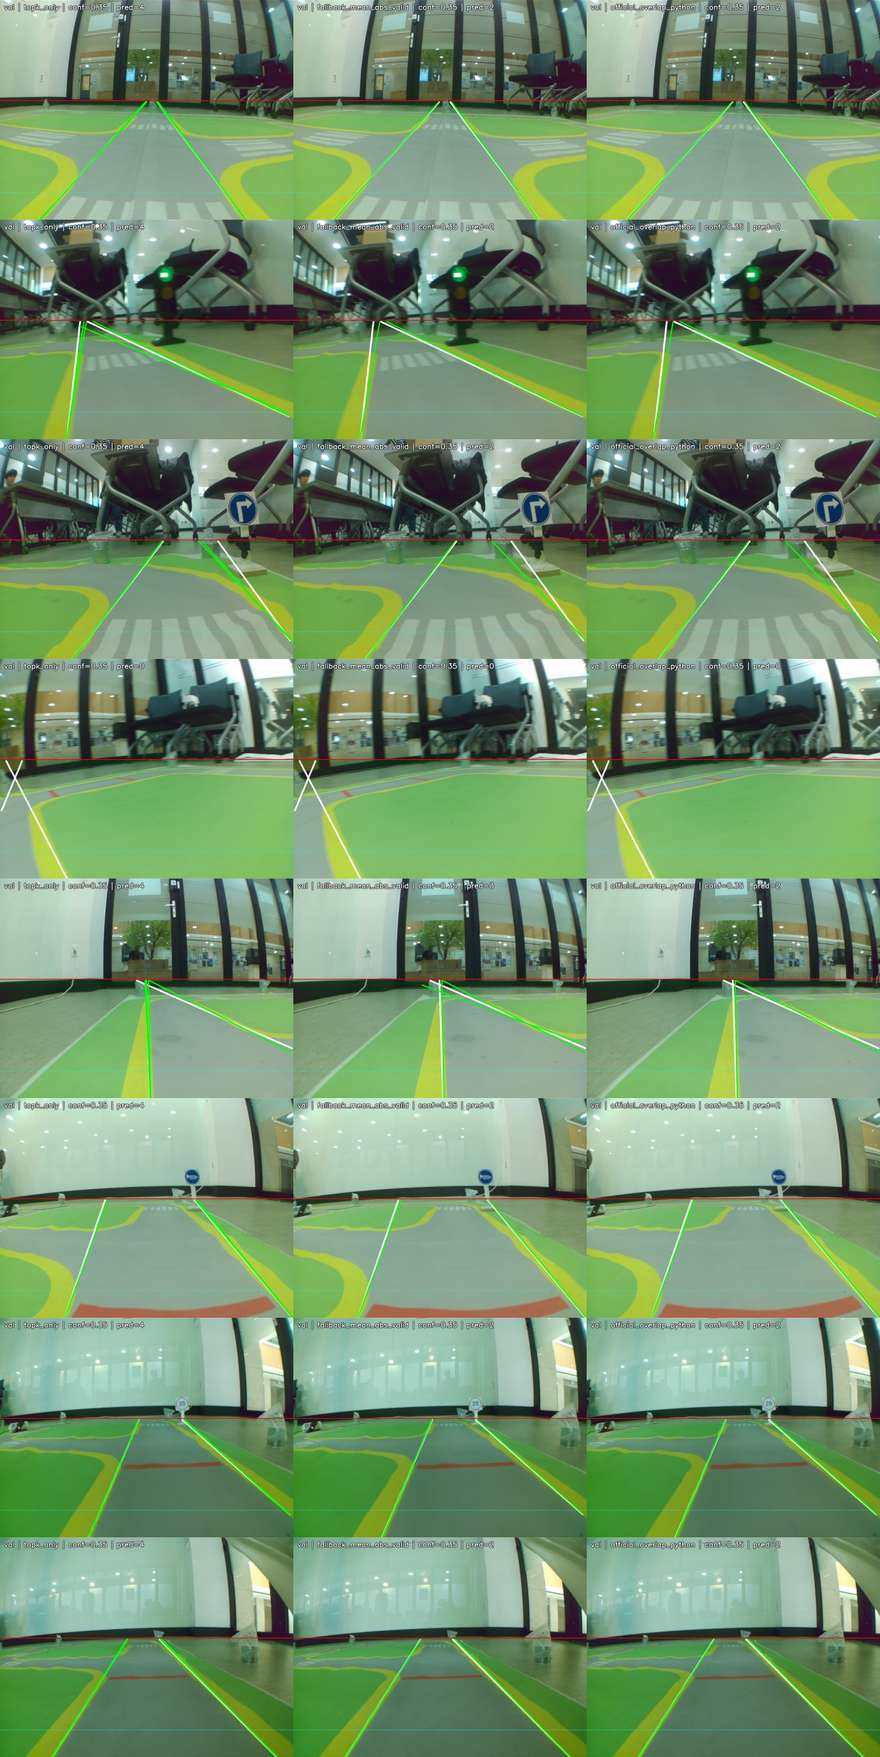

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\overlays\field3_decoder_compare_conf035.jpg


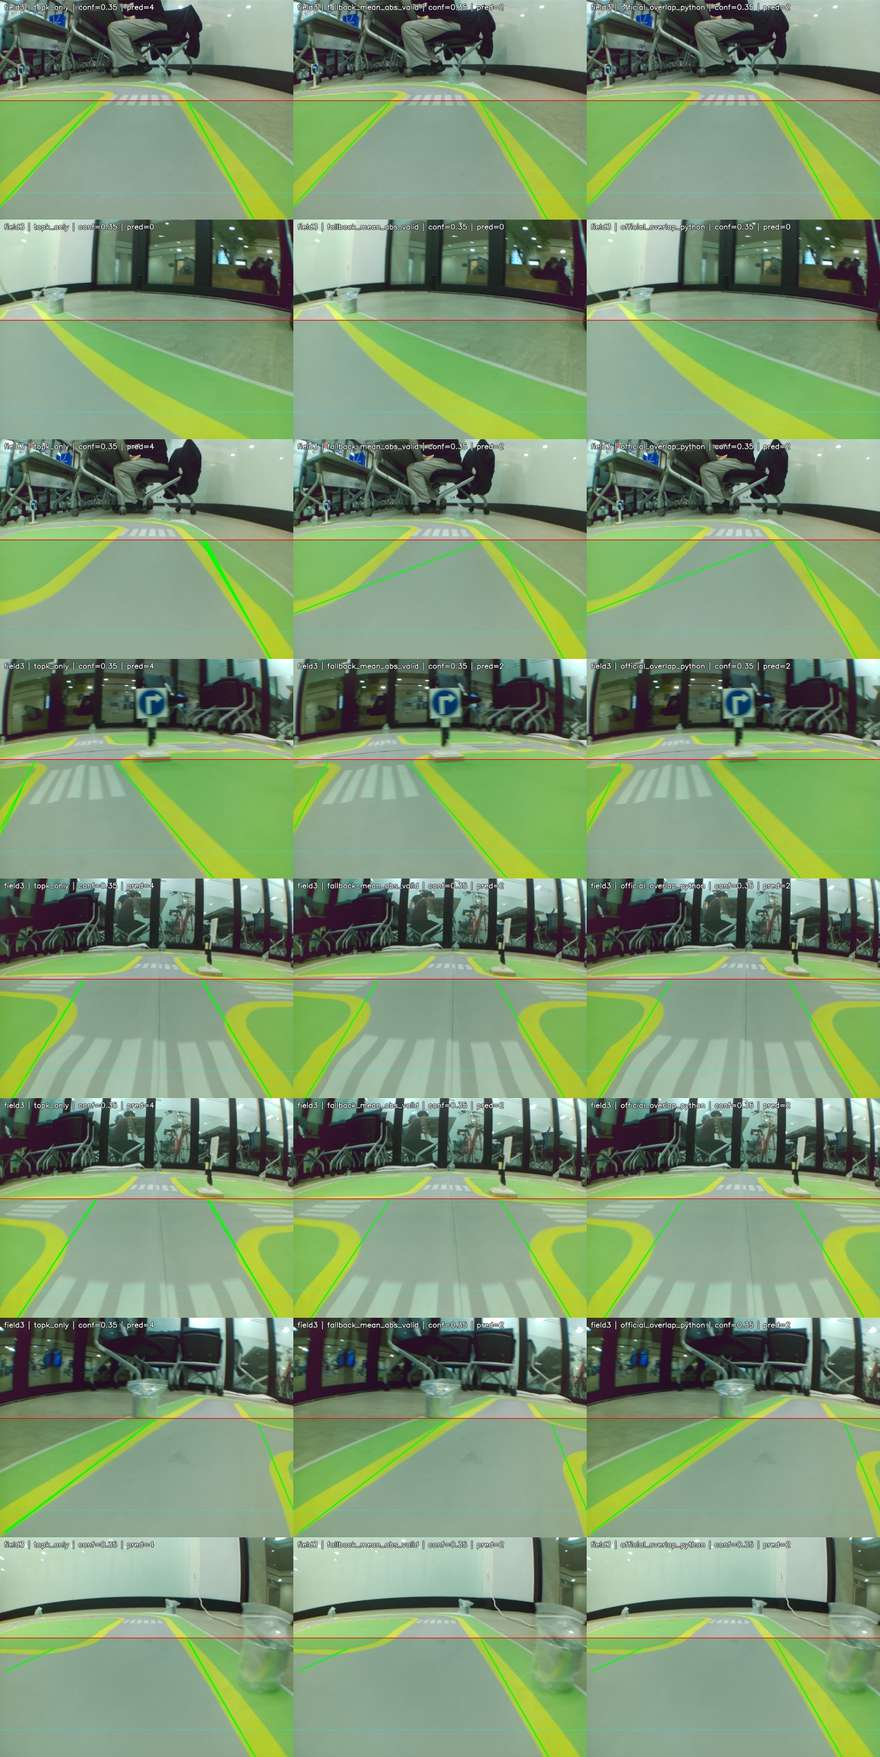

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\overlays\holdout_decoder_compare_conf035.jpg


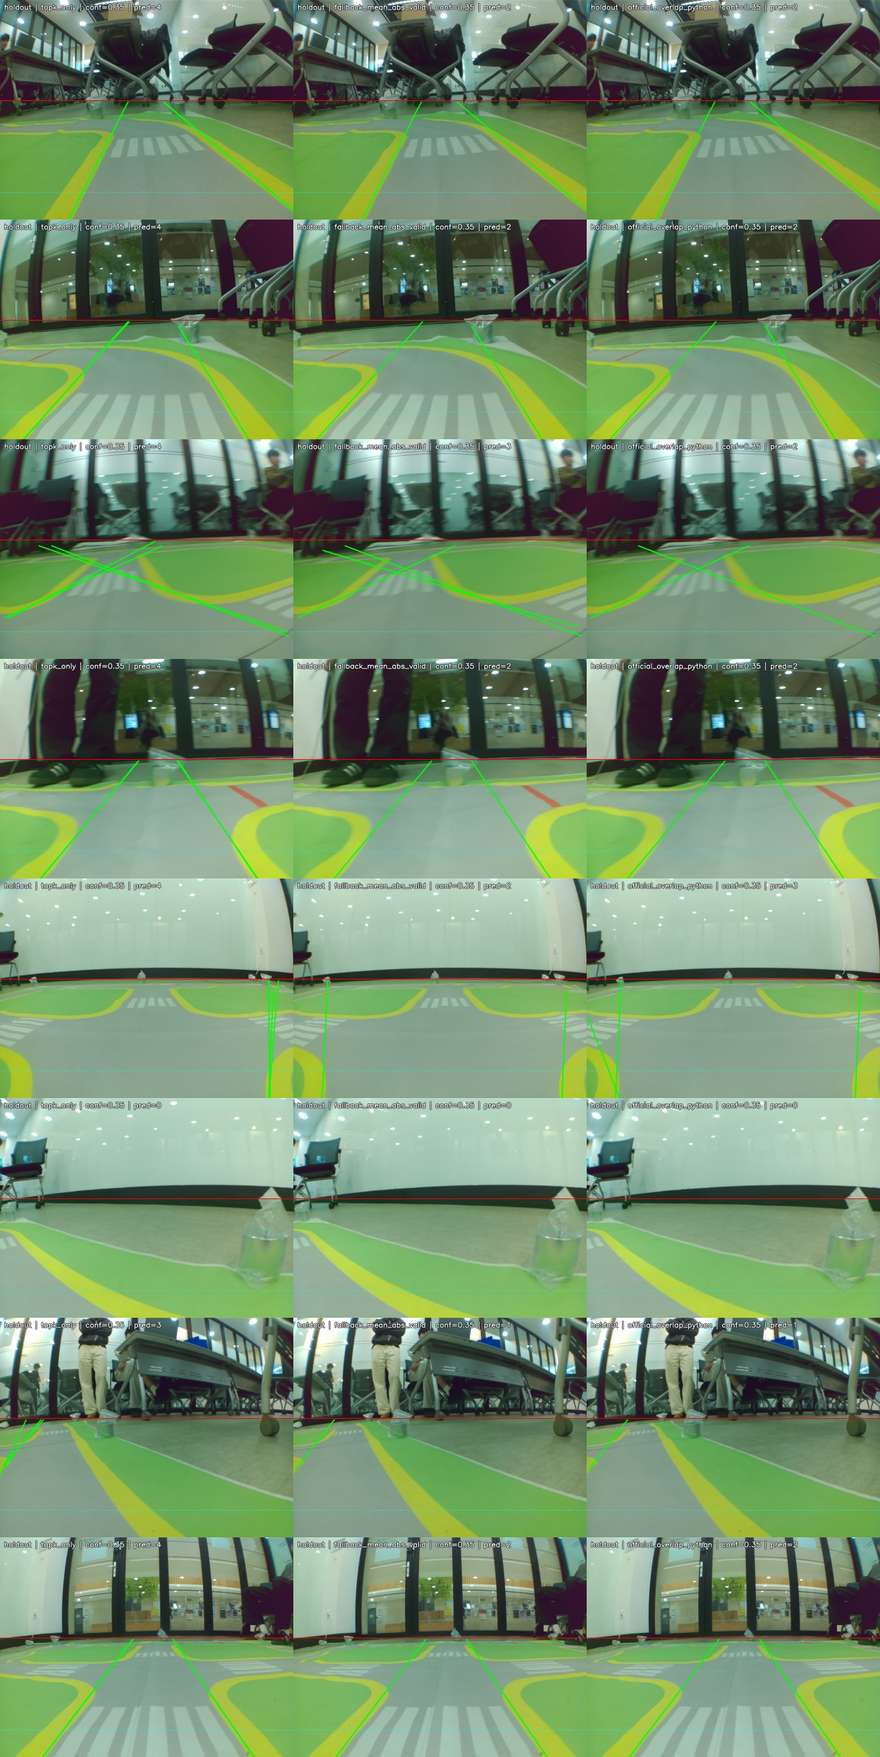

In [13]:
def draw_polyline(out, pts, color, thickness=3):
    pts = np.asarray(pts, dtype=np.float32)
    if len(pts) < 2:
        return
    pts_i = np.round(pts).astype(np.int32)
    for a, b in zip(pts_i[:-1], pts_i[1:]):
        cv2.line(out, tuple(a), tuple(b), color, thickness, cv2.LINE_AA)


def draw_overlay_panel(bgr, gt_lanes, pred_lanes, title):
    out = bgr.copy()
    shade = out.copy()
    cv2.rectangle(shade, (0, cfg.cut_height), (cfg.ori_img_w - 1, cfg.ori_img_h - 1), (0, 80, 0), -1)
    out = cv2.addWeighted(out, 0.82, shade, 0.18, 0)
    cv2.line(out, (0, cfg.cut_height), (cfg.ori_img_w - 1, cfg.cut_height), (0, 0, 255), 2)
    cv2.line(out, (0, 851), (cfg.ori_img_w - 1, 851), (255, 255, 0), 1)
    for gt in gt_lanes:
        draw_polyline(out, gt, (255, 255, 255), thickness=5)
    for lane in pred_lanes:
        draw_polyline(out, lane, (0, 255, 0), thickness=3)
    cv2.putText(out, title, (18, 42), cv2.FONT_HERSHEY_SIMPLEX, 1.05, (0, 0, 0), 5, cv2.LINE_AA)
    cv2.putText(out, title, (18, 42), cv2.FONT_HERSHEY_SIMPLEX, 1.05, (255, 255, 255), 2, cv2.LINE_AA)
    return out


def resize_to_width(img, width):
    h, w = img.shape[:2]
    scale = width / w
    return cv2.resize(img, (width, int(round(h * scale))), interpolation=cv2.INTER_AREA)


def make_sheet(images, out_path, thumb_w=420, cols=3):
    thumbs = [resize_to_width(img, thumb_w) for img in images]
    max_h = max(t.shape[0] for t in thumbs)
    rows = []
    for i in range(0, len(thumbs), cols):
        chunk = thumbs[i:i+cols]
        while len(chunk) < cols:
            chunk.append(np.zeros((max_h, thumb_w, 3), dtype=np.uint8))
        padded = []
        for t in chunk:
            if t.shape[0] < max_h:
                pad = np.zeros((max_h - t.shape[0], t.shape[1], 3), dtype=t.dtype)
                t = np.vstack([t, pad])
            padded.append(t)
        rows.append(np.hstack(padded))
    sheet = np.vstack(rows)
    imwrite_bgr(out_path, sheet)
    return out_path


def overlay_compare_for_records(records, out_name, max_items=8, conf=SELECTED_REVIEW_CONF):
    selected = even_sample(records, max_items)
    panels = []
    for rec in selected:
        key = f"{rec['set']}::{rec['id']}"
        raw = raw_cache[key]
        bgr = imread_bgr(rec['image_path'])
        gt_lanes = parse_lines_txt(rec['gt_path']) if rec.get('gt_path') else []
        for mode in NMS_MODES:
            lane_objs = decode_one(raw, conf, mode, as_lanes=True)
            lane_arrays = [lane_obj_to_array(l, cfg) for l in lane_objs]
            title = f"{rec['set']} | {mode} | conf={conf:.2f} | pred={len(lane_arrays)}"
            panels.append(draw_overlay_panel(bgr, gt_lanes, lane_arrays, title))
    out_path = OVERLAY_DIR / out_name
    make_sheet(panels, out_path, thumb_w=430, cols=3)
    print('saved:', out_path)
    display(Image(filename=str(out_path)))

# Rebuild record lists from manifest paths to keep long-path helpers in one place.
manifest_records = []
for _, row in manifest_df.iterrows():
    gt_value = row['gt_path'] if isinstance(row.get('gt_path'), str) and row.get('gt_path') else None
    manifest_records.append({
        'set': row['set'], 'id': row['id'], 'image_path': Path(row['image_path']),
        'gt_path': Path(gt_value) if gt_value else None, 'rel': row['rel'],
    })

val_sample_records = [r for r in manifest_records if r['set'] == 'val']
field3_sample_records = [r for r in manifest_records if r['set'] == 'field3']
holdout_sample_records = [r for r in manifest_records if r['set'] == 'holdout']

overlay_compare_for_records(val_sample_records, 'val_decoder_compare_conf035.jpg', max_items=8)
overlay_compare_for_records(field3_sample_records, 'field3_decoder_compare_conf035.jpg', max_items=8)
overlay_compare_for_records(holdout_sample_records, 'holdout_decoder_compare_conf035.jpg', max_items=8)

## Field3 sequence video

주행 감각은 단일 overlay보다 시간축에서 더 잘 보인다. 아래 셀은 field3 sample sequence에 대해 NMS mode별 비교 영상을 만든다.

In [14]:
def write_decoder_video(records, out_path, conf=SELECTED_REVIEW_CONF, fps=12):
    if not records:
        print('no records for video')
        return None
    first_bgr = imread_bgr(records[0]['image_path'])
    panels = []
    for mode in NMS_MODES:
        panels.append(draw_overlay_panel(first_bgr, [], [], mode))
    first_sheet = np.hstack([resize_to_width(p, 420) for p in panels])
    h, w = first_sheet.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    tmp_path = Path(out_path)
    tmp_path.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(str(tmp_path), fourcc, fps, (w, h))
    assert writer.isOpened(), f'failed to open video writer: {tmp_path}'
    for rec in tqdm(records, desc=f'write video {tmp_path.name}'):
        key = f"{rec['set']}::{rec['id']}"
        raw = raw_cache[key]
        bgr = imread_bgr(rec['image_path'])
        row_panels = []
        for mode in NMS_MODES:
            lane_objs = decode_one(raw, conf, mode, as_lanes=True)
            lane_arrays = [lane_obj_to_array(l, cfg) for l in lane_objs]
            title = f"{mode} | pred={len(lane_arrays)} | {rec['id'][:30]}"
            row_panels.append(resize_to_width(draw_overlay_panel(bgr, [], lane_arrays, title), 420))
        frame = np.hstack(row_panels)
        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_AREA)
        writer.write(frame)
    writer.release()
    print('saved video:', tmp_path)
    return tmp_path

if WRITE_SEQUENCE_VIDEOS:
    video_path = write_decoder_video(field3_sample_records, VIDEO_DIR / 'field3_decoder_compare_conf035.mp4')
else:
    print('WRITE_SEQUENCE_VIDEOS=False')

write video field3_decoder_compare_conf035.mp4:   0%|          | 0/160 [00:00<?, ?it/s]

saved video: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\videos\field3_decoder_compare_conf035.mp4


## Decode contract 후보 저장

아래 셀은 아직 “최종 확정”이라기보다, 이번 Run All 결과를 사람이 보고 결정할 수 있게 contract 후보를 저장한다.

현재 기본 후보는 `official_overlap_python + conf=0.35`다. 이유는 공식 CUDA NMS 판단을 가장 직접적으로 옮긴 구현이고, PyTorch/ONNX/Pi에서 같은 Python/Numpy 로직으로 재사용할 수 있기 때문이다. 단, 위 summary와 overlay를 보고 `conf_threshold`는 조정할 수 있다.

In [15]:
selected_decode = {
    'name': 'official_overlap_python',
    'conf_threshold': SELECTED_REVIEW_CONF,
    'nms_thres': float(cfg.test_parameters.nms_thres),
    'nms_topk': int(cfg.max_lanes),
    'source': 'Python port of clrkd/ops/csrc/nms_kernel.cu devIoU + greedy keep order',
    'status': 'candidate_after_run_all_review',
}

contract = {
    'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'notebook': '07_decode_contract_v1.ipynb',
    'model_checkpoint': str(BEST_CKPT),
    'config': str(CONFIG_PATH),
    'input_contract': {
        'color_order': 'BGR',
        'range': '[0, 1]',
        'crop': f'raw_y >= cut_height={cfg.cut_height}',
        'resize': [int(cfg.img_w), int(cfg.img_h)],
    },
    'sample_sizes': {
        'val': len(val_sample_records),
        'field3': len(field3_sample_records),
        'holdout': len(holdout_sample_records),
    },
    'compared': {
        'conf_thresholds': CONF_THRESHOLDS,
        'nms_modes': NMS_MODES,
    },
    'selected_decode_candidate': selected_decode,
    'interfaces_to_verify_next': [
        'PyTorch raw output vs ONNX raw output on real images',
        'PyTorch decoded lanes vs ONNX decoded lanes using this same decoder',
        'Local decoded lanes vs Pi decoded lanes using this same decoder',
        'Latency on Pi: preprocess + inference + decode + driving postprocess',
    ],
    'artifacts': {
        'summary_csv': str(TABLE_DIR / 'decode_sweep_summary.csv'),
        'frame_rows_csv': str(TABLE_DIR / 'decode_sweep_frame_rows.csv'),
        'val_overlay': str(OVERLAY_DIR / 'val_decoder_compare_conf035.jpg'),
        'field3_overlay': str(OVERLAY_DIR / 'field3_decoder_compare_conf035.jpg'),
        'holdout_overlay': str(OVERLAY_DIR / 'holdout_decoder_compare_conf035.jpg'),
        'field3_video': str(VIDEO_DIR / 'field3_decoder_compare_conf035.mp4'),
    },
}

contract_path = REVIEW_ROOT / 'decode_contract_candidate.json'
write_text(contract_path, json.dumps(contract, ensure_ascii=False, indent=2))
print('saved contract candidate:', contract_path)
print(json.dumps(contract['selected_decode_candidate'], ensure_ascii=False, indent=2))

saved contract candidate: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\decode_contract_candidate.json
{
  "name": "official_overlap_python",
  "conf_threshold": 0.35,
  "nms_thres": 50.0,
  "nms_topk": 4,
  "source": "Python port of clrkd/ops/csrc/nms_kernel.cu devIoU + greedy keep order",
  "status": "candidate_after_run_all_review"
}


## 1차 비교 후 보강

위쪽 블록은 같은 raw output에서 `topk_only`, `fallback_mean_abs_valid`, `official_overlap_python`을 비교한 1차 ablation이다.

여기서 바로 끝내지 않고, 아래에서는 다음 순서로 decode contract를 확정한다.

1. 왜 `official_overlap_python`이 후보가 되었는지 정량 결과와 공식 구현 관점에서 명시한다.
2. decoder는 `official_overlap_python`으로 고정하고 `conf_threshold`와 `nms_thres`만 sweep한다.
3. 최종 후보를 val 전체 기준으로 재측정한다.
4. `decode_contract_v1.json`에 확정값을 저장한다.

08 노트북은 이 확정된 lane decoder가 뽑은 lane 후보에서 주행용 좌/우 lane과 center를 고르는 **driving decoder contract**를 다룬다.


## 왜 official_overlap_python인가

1차 비교의 목적은 모델 자체를 다시 평가하는 것이 아니라, **같은 모델 raw output에서 어떤 NMS/decoder가 레이블과 가장 비슷하고 주행에 쓸 후보를 안정적으로 남기는지** 보는 것이다.

`topk_only`는 confidence 상위 후보를 거의 그대로 남기기 때문에 같은 lane 주변의 중복 prior가 여러 개 살아남는다. 그래서 prediction 개수가 과하게 많고 false positive가 늘어난다.

`fallback_mean_abs_valid`는 평균 x 거리로 중복을 제거하지만, lane의 시작 y와 길이로 계산되는 **공통 y 구간**을 공식처럼 엄밀히 보지 않는다. 곡선이나 교차로처럼 두 후보의 y 구간이 거의 겹치지 않는 경우에도 평균 x 거리만 가까우면 잘못 suppress할 수 있다.

`official_overlap_python`은 공식 CUDA NMS의 `devIoU`를 Python으로 옮긴 것이다. 이름은 IoU처럼 보이지만 실제 동작은 **공통 y 구간에서 평균 x 거리 < threshold이면 중복 lane으로 보는 방식**이다. 그래서 공식 `get_lanes()`의 NMS 계약과 가장 가깝고, ONNX/Pi runtime에서도 같은 로직을 재사용할 수 있다.


In [16]:
first_pass_summary = pd.read_csv(TABLE_DIR / 'decode_sweep_summary.csv')
val_first_pass = first_pass_summary[first_pass_summary['set'] == 'val'].copy()
val_cols = [
    'conf', 'nms_mode', 'frames', 'precision_proxy', 'recall_proxy', 'f1_proxy',
    'mean_matched_px', 'mean_pred_count', 'pct_no_lane', 'pct_both',
]
val_first_pass = val_first_pass[val_cols].sort_values(['f1_proxy', 'precision_proxy'], ascending=False)
display(val_first_pass)

best_first = val_first_pass.iloc[0].to_dict()
print('1st-pass best:', json.dumps(best_first, ensure_ascii=False, indent=2))
print('Current candidate: official_overlap_python / conf=0.35 / nms_thres=50')


,conf,nms_mode,frames,precision_proxy,recall_proxy,f1_proxy,mean_matched_px,mean_pred_count,pct_no_lane,pct_both
22,0.35,official_overlap_python,96,0.923913,0.904255,0.913978,9.461713,1.916667,0.031250,0.822917
21,0.35,fallback_mean_abs_valid,96,0.904255,0.904255,0.904255,9.461713,1.958333,0.031250,0.822917
24,0.40,fallback_mean_abs_valid,96,0.963855,0.851064,0.903955,8.447315,1.729167,0.062500,0.729167
25,0.40,official_overlap_python,96,0.963855,0.851064,0.903955,8.447315,1.729167,0.062500,0.729167
19,0.30,official_overlap_python,96,0.870000,0.925532,0.896907,9.631483,2.083333,0.020833,0.854167
18,0.30,fallback_mean_abs_valid,96,0.849515,0.930851,0.888325,9.710920,2.145833,0.020833,0.854167
23,0.35,topk_only,96,0.462604,0.888298,0.608379,7.518855,3.760417,0.031250,0.812500
26,0.40,topk_only,96,0.468843,0.840426,0.601905,6.785206,3.510417,0.062500,0.718750
20,0.30,topk_only,96,0.452830,0.893617,0.601073,7.495303,3.864583,0.020833,0.833333


1st-pass best: {
  "conf": 0.35,
  "nms_mode": "official_overlap_python",
  "frames": 96,
  "precision_proxy": 0.9239130434782608,
  "recall_proxy": 0.9042553191489362,
  "f1_proxy": 0.913978494623656,
  "mean_matched_px": 9.461713145235006,
  "mean_pred_count": 1.9166666666666667,
  "pct_no_lane": 0.03125,
  "pct_both": 0.8229166666666666
}
Current candidate: official_overlap_python / conf=0.35 / nms_thres=50


## Official overlap 최종 sweep

이제 decoder 종류는 `official_overlap_python`으로 고정하고, 실제로 조정해야 하는 두 값만 본다.

- `conf_threshold`: 후보 lane을 살릴 최소 confidence. 낮으면 recall이 올라가지만 false positive가 늘 수 있고, 높으면 깔끔해지지만 lane을 놓칠 수 있다.
- `nms_thres`: 공식 overlap NMS에서 두 후보를 같은 lane으로 볼 평균 x 거리 기준(px). 작으면 중복 후보가 살아남기 쉽고, 크면 서로 다른 lane이 하나로 합쳐질 수 있다.

아래 재측정은 기본적으로 val 전체 1722장을 대상으로 한다. NMS threshold는 바꾸지만, proxy F1의 match 기준은 50px로 고정해서 조합 간 비교가 공정하도록 한다. 시간이 너무 오래 걸리면 `FINAL_VAL_LIMIT`만 임시로 줄여서 디버그하고, contract 확정 전에는 다시 `None`으로 돌린다.


In [17]:
OFFICIAL_CONF_SWEEP = [0.30, 0.35, 0.40]
OFFICIAL_NMS_THRES_SWEEP = [30, 50, 70]
OFFICIAL_NMS_MODE = 'official_overlap_python'

# Keep the evaluation rule fixed while sweeping NMS.
FINAL_MATCH_PX = 50.0

# None means full val set. Use a small integer only for temporary debug.
FINAL_VAL_LIMIT = None
RUN_FINAL_VAL_REMEASURE = True

RAW_FULL_VAL_CACHE_PATH = REVIEW_ROOT / 'raw_outputs_val_full.pt'
META_FULL_VAL_CACHE_PATH = REVIEW_ROOT / 'raw_outputs_val_full_manifest.csv'
FINAL_SWEEP_SUMMARY_PATH = TABLE_DIR / 'official_overlap_final_sweep_summary.csv'
FINAL_SWEEP_ROWS_PATH = TABLE_DIR / 'official_overlap_final_sweep_frame_rows.csv'
FINAL_SWEEP_MATCHES_PATH = TABLE_DIR / 'official_overlap_final_sweep_matches.csv'
FINAL_CONTRACT_PATH = REVIEW_ROOT / 'decode_contract_v1.json'

print('official conf sweep:', OFFICIAL_CONF_SWEEP)
print('official nms_thres sweep:', OFFICIAL_NMS_THRES_SWEEP)
print('FINAL_VAL_LIMIT:', FINAL_VAL_LIMIT)
print('fixed proxy match px:', FINAL_MATCH_PX)


official conf sweep: [0.3, 0.35, 0.4]
official nms_thres sweep: [30, 50, 70]
FINAL_VAL_LIMIT: None
fixed proxy match px: 50.0


In [18]:
import inspect

if 'nms_thres' not in inspect.signature(decode_one).parameters:
    print('Current kernel has the older decode_one(); redefining it with nms_thres support.')

    def decode_one(raw_predictions, conf_threshold, nms_mode, as_lanes=True, nms_thres=None):
        predictions = raw_predictions.detach().cpu().clone()
        scores = torch.softmax(predictions[:, :2], dim=1)[:, 1]
        keep_inds = scores >= float(conf_threshold)
        predictions = predictions[keep_inds]
        scores = scores[keep_inds]
        if predictions.shape[0] == 0:
            return [] if as_lanes else predictions

        nms_predictions = prepare_nms_predictions(predictions, head).cpu()
        overlap = cfg.test_parameters.nms_thres if nms_thres is None else float(nms_thres)
        keep, num_to_keep = NMS_IMPLS[nms_mode](
            nms_predictions,
            scores.cpu(),
            overlap=overlap,
            top_k=cfg.max_lanes,
        )
        keep = keep[:num_to_keep]
        selected_scores = scores[keep].clone()
        predictions = predictions[keep]
        if predictions.shape[0] == 0:
            return [] if as_lanes else predictions

        # Geometry stays official; metadata confidence is made human-readable as softmax score.
        predictions[:, 1] = selected_scores
        predictions[:, 5] = torch.round(predictions[:, 5] * head.n_strips)
        if as_lanes:
            return head.predictions_to_pred(predictions)
        return predictions
else:
    print('decode_one already supports nms_thres.')


decode_one already supports nms_thres.


In [19]:
val_full_records = []
for i, rel in enumerate(val_lines):
    img_path = DATASET_DIR / rel.lstrip('/')
    val_full_records.append({
        'key': f'valfull::{i:05d}',
        'set': 'val_full',
        'id': Path(rel).stem,
        'image_path': img_path,
        'gt_path': line_path_for_image(img_path),
        'rel': rel,
    })

val_final_records = even_sample(val_full_records, FINAL_VAL_LIMIT)
print('val final records:', len(val_final_records), 'of', len(val_full_records))
assert val_final_records, 'no final val records found'
for rec in val_final_records[:3]:
    assert exists_path(rec['image_path']), rec['image_path']
    assert exists_path(rec['gt_path']), rec['gt_path']
    print('final val sample:', rec['key'], rec['image_path'].name)


val final records: 1722 of 1722
final val sample: valfull::00000 c32b806f_20260430_160203_lane_none_intersection_none_cent.jpg
final val sample: valfull::00001 af62306d_20260430_160203_lane_none_intersection_none_cent.jpg
final val sample: valfull::00002 eb933da5_20260430_160204_lane_none_intersection_none_cent.jpg


In [20]:
def build_or_load_raw_cache_for_records(records, cache_path, manifest_path, cache_label='raw cache'):
    expected_keys = [r['key'] for r in records]
    if exists_path(cache_path) and exists_path(manifest_path):
        cached_manifest = pd.read_csv(manifest_path)
        cached_keys = cached_manifest['key'].tolist() if 'key' in cached_manifest.columns else []
        if cached_keys == expected_keys:
            print(f'loading existing {cache_label}:', cache_path)
            return torch.load(long_path(cache_path), map_location='cpu'), cached_manifest
        print(f'existing {cache_label} does not match requested records; rebuilding')

    raw_out = {}
    manifest_rows = []
    start_time = time.time()
    for rec in tqdm(records, desc=f'forward {cache_label}'):
        bgr = imread_bgr(rec['image_path'])
        tensor = preprocess_bgr_for_model(bgr, cfg).to(device)
        with torch.no_grad():
            raw = model({'img': tensor}).detach().cpu()[0]
        raw_out[rec['key']] = raw
        manifest_rows.append({
            'key': rec['key'],
            'set': rec['set'],
            'id': rec['id'],
            'image_path': str(rec['image_path']),
            'gt_path': str(rec['gt_path']),
            'rel': rec['rel'],
        })
    torch.save(raw_out, long_path(cache_path))
    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(manifest_path, index=False, encoding='utf-8-sig')
    print(f'saved {cache_label}:', cache_path)
    print('elapsed_min:', round((time.time() - start_time) / 60.0, 2))
    return raw_out, manifest

if RUN_FINAL_VAL_REMEASURE:
    final_raw_cache, final_manifest_df = build_or_load_raw_cache_for_records(
        val_final_records,
        RAW_FULL_VAL_CACHE_PATH,
        META_FULL_VAL_CACHE_PATH,
        cache_label='full val raw cache',
    )
else:
    final_raw_cache, final_manifest_df = {}, pd.DataFrame()
    print('RUN_FINAL_VAL_REMEASURE=False')


loading existing full val raw cache: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\raw_outputs_val_full.pt


In [21]:
def summarize_decode_rows(frame_df, match_df=None):
    summary_rows = []
    for (conf, nms_thres), g in frame_df.groupby(['conf', 'nms_thres']):
        row = {
            'decoder': OFFICIAL_NMS_MODE,
            'conf': float(conf),
            'nms_thres': float(nms_thres),
            'frames': int(len(g)),
            'mean_pred_count': float(g['pred_count'].mean()),
            'pct_no_lane': float((g['pred_count'] == 0).mean()),
            'pct_both': float((g['side_mode'] == 'both').mean()),
            'pct_left_only': float((g['side_mode'] == 'left_only').mean()),
            'pct_right_only': float((g['side_mode'] == 'right_only').mean()),
        }
        centers = g['ego_center_x'].to_numpy(dtype=float)
        valid = np.isfinite(centers)
        row['ego_center_jitter_px'] = float(np.nanmean(np.abs(np.diff(centers[valid])))) if valid.sum() >= 2 else np.nan
        tp = int(g['tp'].sum())
        fp = int(g['fp'].sum())
        fn = int(g['fn'].sum())
        precision, recall, f1 = f1_from_counts(tp, fp, fn)
        row.update({'tp': tp, 'fp': fp, 'fn': fn, 'precision_proxy': precision, 'recall_proxy': recall, 'f1_proxy': f1})
        if match_df is not None and len(match_df):
            m = match_df[(match_df['conf'] == conf) & (match_df['nms_thres'] == nms_thres)]
            row['mean_matched_px'] = float(m['mean_match_px'].mean()) if len(m) else np.nan
        else:
            row['mean_matched_px'] = np.nan
        summary_rows.append(row)
    return pd.DataFrame(summary_rows).sort_values(['f1_proxy', 'precision_proxy', 'recall_proxy'], ascending=False).reset_index(drop=True)

final_rows = []
final_match_rows = []

if RUN_FINAL_VAL_REMEASURE:
    for _, row in tqdm(final_manifest_df.iterrows(), total=len(final_manifest_df), desc='official final sweep'):
        raw = final_raw_cache[row['key']]
        gt_lanes = parse_lines_txt(Path(row['gt_path']))
        for conf in OFFICIAL_CONF_SWEEP:
            for nms_thres in OFFICIAL_NMS_THRES_SWEEP:
                lane_objs = decode_one(raw, conf, OFFICIAL_NMS_MODE, as_lanes=True, nms_thres=nms_thres)
                lane_arrays = [lane_obj_to_array(l, cfg) for l in lane_objs]
                side = side_summary(lane_arrays, img_w=cfg.ori_img_w)
                match = greedy_match_lanes(lane_arrays, gt_lanes, match_px=FINAL_MATCH_PX)
                final_rows.append({
                    'key': row['key'],
                    'id': row['id'],
                    'conf': float(conf),
                    'nms_thres': float(nms_thres),
                    'pred_count': len(lane_arrays),
                    'gt_count': len(gt_lanes),
                    **side,
                    'tp': match['tp'],
                    'fp': match['fp'],
                    'fn': match['fn'],
                })
                for pi, gi, d in match['matches']:
                    final_match_rows.append({
                        'key': row['key'],
                        'id': row['id'],
                        'conf': float(conf),
                        'nms_thres': float(nms_thres),
                        'pred_index': pi,
                        'gt_index': gi,
                        'mean_match_px': d,
                    })

    final_frame_df = pd.DataFrame(final_rows)
    final_match_df = pd.DataFrame(final_match_rows)
    final_summary_df = summarize_decode_rows(final_frame_df, final_match_df)

    final_frame_df.to_csv(FINAL_SWEEP_ROWS_PATH, index=False, encoding='utf-8-sig')
    final_match_df.to_csv(FINAL_SWEEP_MATCHES_PATH, index=False, encoding='utf-8-sig')
    final_summary_df.to_csv(FINAL_SWEEP_SUMMARY_PATH, index=False, encoding='utf-8-sig')

    display(final_summary_df)
    print('saved final summary:', FINAL_SWEEP_SUMMARY_PATH)
else:
    final_frame_df = pd.DataFrame()
    final_match_df = pd.DataFrame()
    final_summary_df = pd.DataFrame()


official final sweep:   0%|          | 0/1722 [00:00<?, ?it/s]

,decoder,conf,nms_thres,frames,mean_pred_count,pct_no_lane,pct_both,pct_left_only,pct_right_only,ego_center_jitter_px,tp,fp,fn,precision_proxy,recall_proxy,f1_proxy,mean_matched_px
0,official_overlap_python,0.35,70.0,1722,1.849013,0.027875,0.794425,0.065621,0.112079,57.775626,3001,183,353,0.942525,0.894753,0.918018,8.630944
1,official_overlap_python,0.35,50.0,1722,1.878049,0.027875,0.795587,0.065041,0.111498,57.343079,3015,219,339,0.932282,0.898927,0.915301,8.672943
2,official_overlap_python,0.30,70.0,1722,1.980836,0.004646,0.835075,0.054007,0.106272,48.484406,3074,337,280,0.901202,0.916518,0.908795,8.966141
3,official_overlap_python,0.40,50.0,1722,1.709640,0.049942,0.693380,0.072590,0.184088,78.811213,2836,108,518,0.963315,0.845558,0.900603,7.921264
4,official_overlap_python,0.40,70.0,1722,1.708479,0.049942,0.693380,0.072590,0.184088,78.912586,2834,108,520,0.963290,0.844961,0.900254,7.917705
5,official_overlap_python,0.40,30.0,1722,1.746806,0.049942,0.700929,0.065041,0.184088,78.448761,2846,162,508,0.946144,0.848539,0.894687,7.887270
6,official_overlap_python,0.30,50.0,1722,2.103368,0.004646,0.836237,0.053426,0.105691,47.541094,3116,506,238,0.860298,0.929040,0.893349,9.131696
7,official_overlap_python,0.35,30.0,1722,2.027294,0.027875,0.805459,0.056911,0.109756,57.304193,3037,454,317,0.869951,0.905486,0.887363,8.443673
8,official_overlap_python,0.30,30.0,1722,2.437282,0.004646,0.856562,0.044715,0.094077,47.247229,3156,1041,198,0.751966,0.940966,0.835916,8.616016


saved final summary: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\tables\official_overlap_final_sweep_summary.csv


In [22]:
assert len(final_summary_df), 'final_summary_df is empty; run the final sweep before writing the contract'
selected_final = final_summary_df.iloc[0].to_dict()

selected_decode_final = {
    'name': OFFICIAL_NMS_MODE,
    'conf_threshold': float(selected_final['conf']),
    'nms_thres': float(selected_final['nms_thres']),
    'nms_topk': int(cfg.max_lanes),
    'source': 'Python port of clrkd/ops/csrc/nms_kernel.cu devIoU + greedy keep order',
    'status': 'selected_after_full_val_sweep',
    'selection_rule': 'highest val proxy F1, tie-broken by precision then recall',
    'confidence_metadata': 'lane.metadata["conf"] is stored as softmax positive-lane score in [0, 1], not raw cls logit.',
}

final_contract = {
    'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'notebook': '07_decode_contract_v1.ipynb',
    'model_checkpoint': str(BEST_CKPT),
    'config': str(CONFIG_PATH),
    'input_contract': {
        'color_order': 'BGR',
        'range': '[0, 1]',
        'crop': f'raw_y >= cut_height={cfg.cut_height}',
        'resize': [int(cfg.img_w), int(cfg.img_h)],
    },
    'decoder_contract': selected_decode_final,
    'final_val_proxy_metric': {
        k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
        for k, v in selected_final.items()
    },
    'first_pass_compared': {
        'conf_thresholds': CONF_THRESHOLDS,
        'nms_modes': NMS_MODES,
        'sample_sizes': {
            'val': len(val_sample_records),
            'field3': len(field3_sample_records),
            'holdout': len(holdout_sample_records),
        },
    },
    'final_sweep_compared': {
        'decoder': OFFICIAL_NMS_MODE,
        'conf_thresholds': OFFICIAL_CONF_SWEEP,
        'nms_thres_values': OFFICIAL_NMS_THRES_SWEEP,
        'proxy_match_px': FINAL_MATCH_PX,
        'val_frames': int(selected_final['frames']),
    },
    'interfaces_to_verify_next': [
        'PyTorch raw output vs ONNX raw output on real images',
        'PyTorch decoded lanes vs ONNX decoded lanes using this same decoder',
        'Local decoded lanes vs Pi decoded lanes using this same decoder',
        'Latency on Pi: preprocess + inference + decode + driving postprocess',
    ],
    'artifacts': {
        'first_pass_summary_csv': str(TABLE_DIR / 'decode_sweep_summary.csv'),
        'final_sweep_summary_csv': str(FINAL_SWEEP_SUMMARY_PATH),
        'final_sweep_frame_rows_csv': str(FINAL_SWEEP_ROWS_PATH),
        'final_sweep_matches_csv': str(FINAL_SWEEP_MATCHES_PATH),
        'contract_json': str(FINAL_CONTRACT_PATH),
    },
}

write_text(FINAL_CONTRACT_PATH, json.dumps(final_contract, ensure_ascii=False, indent=2))
print('saved final decode contract:', FINAL_CONTRACT_PATH)
print(json.dumps(final_contract['decoder_contract'], ensure_ascii=False, indent=2))


saved final decode contract: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\07_decode_contract_v1\decode_contract_v1.json
{
  "name": "official_overlap_python",
  "conf_threshold": 0.35,
  "nms_thres": 70.0,
  "nms_topk": 4,
  "source": "Python port of clrkd/ops/csrc/nms_kernel.cu devIoU + greedy keep order",
  "status": "selected_after_full_val_sweep",
  "selection_rule": "highest val proxy F1, tie-broken by precision then recall",
  "confidence_metadata": "lane.metadata[\"conf\"] is stored as softmax positive-lane score in [0, 1], not raw cls logit."
}


## 07 결론 확인

`decode_contract_v1.json`이 생성되면 07의 역할은 끝난다.

이 파일은 이후 노트북들이 따라야 할 lane decoder 계약이다.

- 08: 이 decoder가 뽑은 lane 후보에서 주행용 left/right/center를 고른다.
- 09: `.pth`와 `.onnx`가 같은 raw output과 같은 decoded lanes를 내는지 검증한다.
- 10: Pi에서 같은 decoder를 적용했을 때 local과 같은 결과가 나오는지, 그리고 latency가 충분한지 확인한다.

만약 08이나 Pi replay에서 특정 상황의 lane 출력이 불안정하면, 02 라벨 정책 또는 07 decoder 파라미터로 되돌아와 새 버전을 만든다.
